<a href="https://colab.research.google.com/github/saini18-eng/project-task/blob/flow/Spam_SMS_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📁 Step 1: Upload the Dataset

In [1]:
from google.colab import files
uploaded = files.upload()


Saving spam.sms.detection.zip to spam.sms.detection.zip


📦 Step 2: Extract the ZIP file

In [2]:
import zipfile

with zipfile.ZipFile("spam.sms.detection.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")


📊 Step 3: Load and Explore the Data

In [4]:
import os

# List files in the dataset directory
files_in_dataset = os.listdir("dataset")
print(files_in_dataset)

['spam.csv']


In [5]:
import pandas as pd

df = pd.read_csv("dataset/spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('message').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('index', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('label')):
  _plot_series(series, series_name, i)
  fig.legend(title='label', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

...

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['message'].value_counts()
    for x_label, grp in _df_6.groupby('label')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('label')
_ = plt.ylabel('message')

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_7['label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_7, x='index', y='label', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_8['message'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_8, x='index', y='message', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

🧹 Step 4: Preprocess the Data

In [6]:
# Convert 'ham' and 'spam' to 0 and 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Check for null values
df.isnull().sum()


,0
label,0
message,0


🧪 Step 5: Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


🔤 Step 6: TF-IDF Vectorization

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


🤖 Step 7: Train Models

🔹 Naive Bayes

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
y_pred_nb = nb.predict(X_test_vec)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.9668161434977578
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



🔹 Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_vec, y_train)
y_pred_lr = lr.predict(X_test_vec)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9524663677130045


🔹 Support Vector Machine (SVM)

In [11]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_vec, y_train)
y_pred_svm = svm.predict(X_test_vec)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.97847533632287


✉️ Step 8: Predict on New SMS

In [12]:
def predict_spam(sms):
    vec = vectorizer.transform([sms])
    pred = nb.predict(vec)  # You can use lr or svm instead
    return "Spam" if pred[0] else "Ham"

predict_spam("Congratulations! You've won a free trip to Maldives.")


'Ham'


💾 Step 9: Save Model

In [13]:
import joblib

joblib.dump(nb, 'spam_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']

✅ Step 10: Evaluate with Confusion Matrix

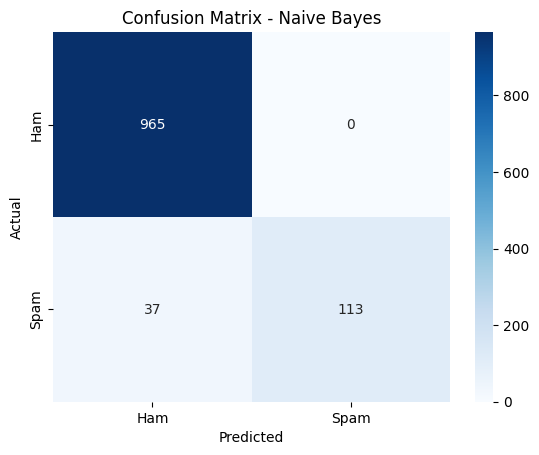

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb)  # or y_pred_lr / y_pred_svm
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()


✅ Step 11: Try on Multiple Inputs (Custom SMS List)

In [15]:
sms_list = [
    "Your OTP is 734827. Do not share it with anyone.",
    "Get free recharge now! Visit spam.com",
    "Hello! Are we still on for lunch?",
    "Win ₹10,000 cash now by clicking this link!"
]

for sms in sms_list:
    result = predict_spam(sms)
    print(f"Message: {sms}\nPrediction: {result}\n")


Message: Your OTP is 734827. Do not share it with anyone.
Prediction: Ham

Message: Get free recharge now! Visit spam.com
Prediction: Ham

Message: Hello! Are we still on for lunch?
Prediction: Ham

Message: Win ₹10,000 cash now by clicking this link!
Prediction: Spam



✅ Step 12: Add Simple UI

In [16]:
sms_input = input("Enter an SMS message to classify: ")
print("Prediction:", predict_spam(sms_input))


Enter an SMS message to classify:  Message: Hello! Are we still on for lunch
Prediction: Ham


✅ Step 13: Export Predictions to CSV

In [18]:
df['prediction'] = nb.predict(vectorizer.transform(df['message']))

df['prediction'] = df['prediction'].map({0: 'Ham', 1: 'Spam'})
df.to_csv("predicted_spam_messages.csv", index=False)

from google.colab import files
files.download("predicted_spam_messages.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Step 13: Use SMOTE to Handle Class Imbalance

✅ 1. Install imbalanced-learn library

In [19]:
!pip install imbalanced-learn


✅ 2. Apply SMOTE after Vectorization

In [20]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE on TF-IDF vectors
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_vec, y_train)

print("Before SMOTE:", X_train_vec.shape, y_train.value_counts())
print("After SMOTE:", X_train_smote.shape, y_train_smote.value_counts())


Before SMOTE: (4457, 7472) label
0    3860
1     597
Name: count, dtype: int64
After SMOTE: (7720, 7472) label
0    3860
1    3860
Name: count, dtype: int64


✅ 3. Train Models on Balanced Data

🔹 Naive Bayes (after SMOTE)

In [21]:
nb_smote = MultinomialNB()
nb_smote.fit(X_train_smote, y_train_smote)
y_pred_nb_smote = nb_smote.predict(X_test_vec)

print("Naive Bayes with SMOTE Accuracy:", accuracy_score(y_test, y_pred_nb_smote))
print(classification_report(y_test, y_pred_nb_smote))


Naive Bayes with SMOTE Accuracy: 0.9650224215246637
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       965
           1       0.84      0.92      0.88       150

    accuracy                           0.97      1115
   macro avg       0.91      0.95      0.93      1115
weighted avg       0.97      0.97      0.97      1115



🔹 Logistic Regression / SVM

In [22]:
lr_smote = LogisticRegression()
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test_vec)

print("Logistic Regression with SMOTE Accuracy:", accuracy_score(y_test, y_pred_lr_smote))


Logistic Regression with SMOTE Accuracy: 0.9757847533632287
